# 09 — Compression impact (size, latency, validation quality)

Run **after** notebook `08` (or any trained float taxonomy `.pt`). Compares **four** stages:

1. **Baseline** — original float checkpoint on disk (no compression pipeline).
2. **+ Prune** — L1 head pruning only (still float on disk).
3. **+ INT8** — prune + dynamic quantization (`.pt` blob, no Huffman).
4. **+ Huffman** — full pipeline as in `08` (smallest file).

**Metrics:** file size (MB), **CPU** forward time per image (dummy batch), val **species** (and family/genus) **acc@1** and **F1 macro**.

Set `SRC` to the same float checkpoint as in `08`. Requires `data/manifests/fishnet_taxonomy_val.jsonl`. Optional: set `MAX_VAL_SAMPLES` to cap val set for a quicker run.


In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset

ROOT = Path('..').resolve()
sys.path.insert(0, str((ROOT / 'src').resolve()))

from fish_ai.compress import (
    TaxonomyCompressionConfig,
    compress_taxonomy_checkpoint,
    load_float_taxonomy_from_ckpt,
    load_taxonomy_checkpoint_auto,
    load_taxonomy_for_inference,
    validate_taxonomy_checkpoint_file,
)
from fish_ai.data.taxonomy_dataset import FishTaxonomyDataset
from fish_ai.train.taxonomy_train import evaluate

OUT = ROOT / 'outputs'
MANIFEST_DIR = ROOT / 'data' / 'manifests'

# Same float source as notebook 08
SRC = (OUT / 'taxonomy_ssl' / 'taxonomy_ssl_resnet50.pt').resolve()
# SRC = (OUT / 'federated_fedavg' / 'fedavg_global_model.pt').resolve()

TMP_DIR = (OUT / 'compression_ablation_tmp').resolve()
VAL_MANIFEST = MANIFEST_DIR / 'fishnet_taxonomy_val.jsonl'

# None = full val set; e.g. 2048 for faster iteration
MAX_VAL_SAMPLES = None

BENCH_BATCH = 8
BENCH_WARMUP = 4
BENCH_ITERS = 25

BATCH_SIZE = 32
NUM_WORKERS = 0

TMP_DIR.mkdir(parents=True, exist_ok=True)
print('SRC:', SRC, 'exists:', SRC.is_file())
print('VAL_MANIFEST:', VAL_MANIFEST, 'exists:', VAL_MANIFEST.is_file())


SRC: D:\Fish Codes\outputs\taxonomy_ssl\taxonomy_ssl_resnet50.pt exists: True
VAL_MANIFEST: D:\Fish Codes\data\manifests\fishnet_taxonomy_val.jsonl exists: True


In [2]:
def bench_ms_per_image(model: torch.nn.Module, device: torch.device, batch: int = 8, warmup: int = 4, iters: int = 25) -> float:
    model.to(device).eval()
    x = torch.randn(batch, 3, 224, 224, device=device)
    with torch.inference_mode():
        for _ in range(warmup):
            model(x)
        t0 = time.perf_counter()
        for _ in range(iters):
            model(x)
        dt = time.perf_counter() - t0
    return float(dt / (iters * batch) * 1000.0)


cpu = torch.device('cpu')
if not SRC.is_file():
    raise FileNotFoundError(f'Missing float checkpoint: {SRC} (train in 03–05 or fix SRC)')

validate_taxonomy_checkpoint_file(SRC)
base_ckpt = torch.load(SRC, map_location='cpu', weights_only=False)
maps = base_ckpt['maps']

ds_val_full = FishTaxonomyDataset(VAL_MANIFEST, image_size=224, augment=False, max_side_before_square=512)
if MAX_VAL_SAMPLES is not None:
    n = min(MAX_VAL_SAMPLES, len(ds_val_full))
    ds_val = Subset(ds_val_full, range(n))
    print(f'Using first {n} val samples (MAX_VAL_SAMPLES)')
else:
    ds_val = ds_val_full
    print('Val samples:', len(ds_val))

loader_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

SPECS = [
    ('1_baseline_float', None),
    ('2_prune_only', TaxonomyCompressionConfig(apply_prune=True, quantize=False, huffman_wrap=False)),
    ('3_prune_INT8', TaxonomyCompressionConfig(apply_prune=True, quantize=True, huffman_wrap=False)),
    ('4_full_Huffman', TaxonomyCompressionConfig(apply_prune=True, quantize=True, huffman_wrap=True)),
]

rows = []
paths_to_cleanup = []

for label, cfg in SPECS:
    if cfg is None:
        path = SRC
        file_bytes = path.stat().st_size
        ckpt = base_ckpt
        model = load_float_taxonomy_from_ckpt(ckpt)
        bench_dev = cpu
        eval_dev = cpu
    else:
        suffix = '.huff.pt' if cfg.huffman_wrap else '.pt'
        path = TMP_DIR / (label + suffix)
        paths_to_cleanup.append(path)
        rep = compress_taxonomy_checkpoint(SRC, path, cfg)
        file_bytes = int(rep['file_bytes'])
        ckpt = load_taxonomy_checkpoint_auto(path, map_location='cpu')
        model = load_taxonomy_for_inference(ckpt)
        comp = ckpt.get('compression') or {}
        bench_dev = cpu
        eval_dev = cpu

    ms_img = bench_ms_per_image(model, bench_dev, batch=BENCH_BATCH, warmup=BENCH_WARMUP, iters=BENCH_ITERS)
    metrics = evaluate(model, loader_val, eval_dev, maps)

    row = {
        'variant': label,
        'file_MB': file_bytes / 1e6,
        'cpu_ms_per_image': ms_img,
        'species_acc': float(metrics['species']['acc_top1']),
        'species_f1_macro': float(metrics['species']['f1_macro']),
        'genus_acc': float(metrics['genus']['acc_top1']),
        'family_acc': float(metrics['family']['acc_top1']),
    }
    rows.append(row)
    print(row)

# Optional: remove temp artifacts (keep for inspection if you prefer)
for p in paths_to_cleanup:
    try:
        p.unlink()
    except OSError:
        pass

df = pd.DataFrame(rows)
df


Val samples: 4188
{'variant': '1_baseline_float', 'file_MB': 97.565978, 'cpu_ms_per_image': 13.498927000000549, 'species_acc': 0.9813753581661891, 'species_f1_macro': 0.40084661277006717, 'genus_acc': 0.7175262655205349, 'family_acc': 0.7633715377268386}
{'variant': '2_prune_only', 'file_MB': 97.55665, 'cpu_ms_per_image': 12.983560499997111, 'species_acc': 0.9813753581661891, 'species_f1_macro': 0.4202064055789278, 'genus_acc': 0.7172874880611271, 'family_acc': 0.7626552053486151}


d:\Fish Codes\.venv\Lib\site-packages\torch\_utils.py:410: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  device=storage.device,


{'variant': '3_prune_INT8', 'file_MB': 95.162718, 'cpu_ms_per_image': 12.93546900000365, 'species_acc': 0.9811365807067812, 'species_f1_macro': 0.404135364369749, 'genus_acc': 0.7180038204393505, 'family_acc': 0.7636103151862464}
{'variant': '4_full_Huffman', 'file_MB': 88.531594, 'cpu_ms_per_image': 15.381022500005201, 'species_acc': 0.9811365807067812, 'species_f1_macro': 0.404135364369749, 'genus_acc': 0.7180038204393505, 'family_acc': 0.7636103151862464}


,variant,file_MB,cpu_ms_per_image,species_acc,species_f1_macro,genus_acc,family_acc
0,1_baseline_float,97.565978,13.498927,0.981375,0.400847,0.717526,0.763372
1,2_prune_only,97.556650,12.983560,0.981375,0.420206,0.717287,0.762655
2,3_prune_INT8,95.162718,12.935469,0.981137,0.404135,0.718004,0.763610
3,4_full_Huffman,88.531594,15.381023,0.981137,0.404135,0.718004,0.763610


## Plots

Bar charts share the same x-order as the table. **Latency** is CPU forward on a dummy tensor (relative comparison). **Quality** is full val pass unless you set `MAX_VAL_SAMPLES`.


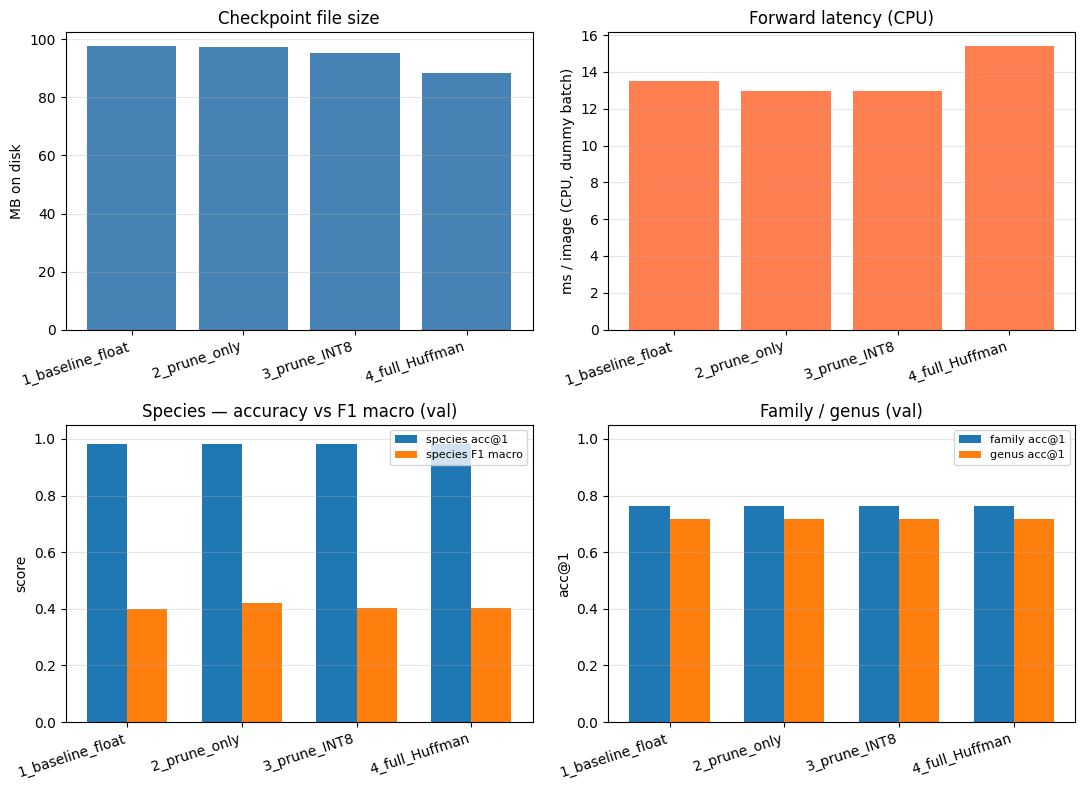

In [3]:
labels = [r['variant'] for r in rows]
x = np.arange(len(labels))
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
ax.bar(x, df['file_MB'], color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=18, ha='right')
ax.set_ylabel('MB on disk')
ax.set_title('Checkpoint file size')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[0, 1]
ax.bar(x, df['cpu_ms_per_image'], color='coral')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=18, ha='right')
ax.set_ylabel('ms / image (CPU, dummy batch)')
ax.set_title('Forward latency (CPU)')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[1, 0]
w = 0.35
ax.bar(x - w / 2, df['species_acc'], width=w, label='species acc@1')
ax.bar(x + w / 2, df['species_f1_macro'], width=w, label='species F1 macro')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=18, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('score')
ax.set_title('Species — accuracy vs F1 macro (val)')
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=0.3)

ax = axes[1, 1]
ax.bar(x - w / 2, df['family_acc'], width=w, label='family acc@1')
ax.bar(x + w / 2, df['genus_acc'], width=w, label='genus acc@1')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=18, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('acc@1')
ax.set_title('Family / genus (val)')
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
